# IMPORT LIBRARY

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture

cv2: dùng để đọc và xử lý ảnh

numpy: xử lý dữ liệu dạng mảng

matplotlib: hiển thị ảnh

GaussianMixture (sklearn): mô hình hỗn hợp Gaussian dùng để phân cụm không giám sát

# Đọc và hiển thị ảnh

(np.float64(-0.5), np.float64(585.5), np.float64(390.5), np.float64(-0.5))

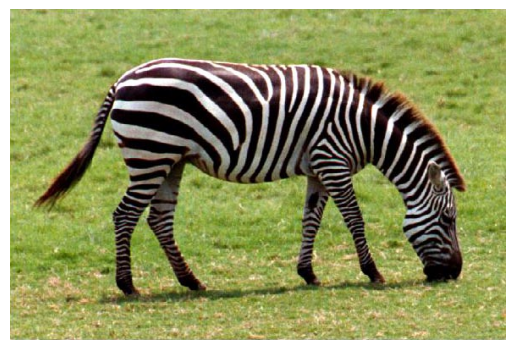

In [3]:
img = cv2.imread('/content/zebra.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')

OpenCV mặc định đọc ảnh ở hệ màu BGR, trong khi matplotlib sử dụng RGB, do đó cần chuyển đổi

Việc kiểm tra img is None giúp phát hiện sớm lỗi dữ liệu đầu vào, đảm bảo tính ổn định của chương trình

# Chuẩn bị dữ liệu cho GMM

In [4]:
# Lấy kích thước ảnh
h, w, c = img.shape

# Reshape ảnh thành (N, 3)
pixels = img.reshape(-1, 3)

Mỗi pixel được xem như một điểm dữ liệu trong không gian 3 chiều (R, G, B)

Ảnh kích thước (h × w × 3) được chuyển thành (h·w × 3)

Cách biểu diễn này cho phép áp dụng trực tiếp các thuật toán phân cụm của học máy

# Huấn luyện Gaussian Mixture Model

In [5]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(pixels)

# Dự đoán nhãn cho từng pixel
labels = gmm.predict(pixels)


n_components = 2: giả định ảnh gồm 2 vùng chính: đối tượng (ngựa vằn) và nền (cỏ)

GMM mô hình hóa phân bố màu của mỗi vùng bằng phân phối Gaussian

Mô hình được huấn luyện không giám sát, không cần nhãn trước

Mỗi pixel sau đó được gán vào một cụm tương ứng

# Xác định đâu là nền

In [6]:
# Đếm số pixel của mỗi cụm
unique, counts = np.unique(labels, return_counts=True)

background_label = unique[np.argmax(counts)]
foreground_label = unique[np.argmin(counts)]


Trong ảnh tự nhiên, nền thường chiếm diện tích lớn hơn đối tượng

Do đó, cụm có số lượng pixel nhiều nhất được xem là nền

Cụm còn lại được xem là đối tượng chính

# Xóa nền

In [7]:
# Tạo ảnh kết quả
segmented = pixels.copy()

segmented[labels == background_label] = [0, 0, 0]

# Reshape lại ảnh
segmented_img = segmented.reshape(h, w, 3)

Các pixel thuộc cụm nền được gán về màu đen

Pixel thuộc đối tượng được giữ nguyên giá trị màu ban đầu

Ảnh kết quả được reshape về kích thước ban đầu để hiển thị

# Hiển thị kết quả

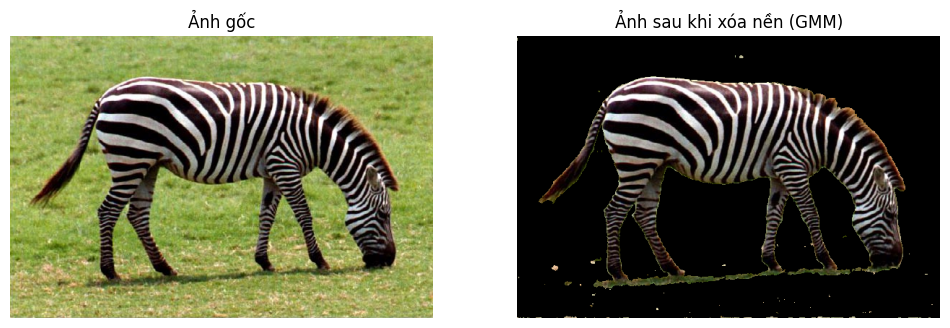

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Ảnh gốc")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Ảnh sau khi xóa nền (GMM)")
plt.imshow(segmented_img)
plt.axis('off')

plt.show()


So sánh trực quan giữa ảnh gốc và ảnh sau khi xóa nền

# Nhận xét và đánh giá phương pháp

Ưu điểm:

- Không cần dữ liệu gán nhãn

- Dễ triển khai, phù hợp cho các bài toán thử nghiệm

- Hoạt động tốt khi nền và đối tượng có sự khác biệt rõ về màu sắc

Hạn chế:

- Nhạy cảm với nền phức tạp

- Không tận dụng thông tin không gian của pixel

- Có thể phân đoạn sai tại vùng rìa